<a href="https://colab.research.google.com/github/cibelerusso/Modelos-de-Regressao/blob/master/Algebra%20Matricial/EST5507_Inversa_matriz_em_blocos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inversão de matriz bloco-diagonal


## EST5507 Modelos de Regressão

## Profa. Cibele Russo - ICMC USP


Notebook elaborado com o apoio de ferramentas de IA generativa (ChatGPT).






# Inversão de matrizes bloco-diagonais: matriz completa vs. blocos

Este notebook compara duas estratégias para inverter uma matriz bloco-diagonal:

1. Construir a matriz bloco-diagonal completa e aplicar `np.linalg.inv`;
2. Inverter cada bloco separadamente.

Se

$
A = \operatorname{diag}(A_1, A_2, \ldots, A_k),
$

então

$
A^{-1} = \operatorname{diag}(A_1^{-1}, A_2^{-1}, \ldots, A_k^{-1}).
$

Se cada bloco tem dimensão $b \times b$, então a matriz completa tem dimensão $kb \times kb$.


Explorar explicitamente a estrutura bloco-diagonal pode produzir uma redução substancial no custo computacional.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from time import perf_counter

rng = np.random.default_rng(123)



## 1. Geração dos blocos

Vamos gerar matrizes simétricas definidas positivas. Isso garante que os blocos sejam inversíveis e evita problemas numéricos desnecessários na simulação.


In [ ]:

def make_spd_blocks(k, b, rng):
    """Gera k matrizes simétricas positiva-definidas de dimensão b x b."""
    blocks = []

    for _ in range(k):
        X = rng.standard_normal((b, b))
        A = X @ X.T + b * np.eye(b)
        blocks.append(A)

    return blocks



## 2. Exemplo simples

Primeiro, verificamos numericamente que inverter a matriz completa ou inverter cada bloco separadamente produz o mesmo resultado, a menos de erro de ponto flutuante.


In [ ]:
k = 4
b = 3

blocks = make_spd_blocks(k, b, rng)

A = block_diag(*blocks)

Ainv_grande = np.linalg.inv(A)

inv_blocks = [np.linalg.inv(B) for B in blocks]
Ainv_blocos = block_diag(*inv_blocks)

erro = np.linalg.norm(Ainv_grande - Ainv_blocos, ord=np.inf)

print("Dimensão da matriz completa:", A.shape)
print("Erro máximo entre as duas inversas:", erro)


Dimensão da matriz completa: (12, 12)
Erro máximo entre as duas inversas: 0.0


In [ ]:
np.round(A)

array([[ 6.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  5., -2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -2.,  6., -2.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1., -2.,  6.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  8., -2., -3.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -2.,  7.,  2.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -3.,  2.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4., -1., -2.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  6.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -2.,  1.,  8.]])


## 3. Função de benchmark (teste padronizado de desempenho)

Para reduzir o efeito de flutuações de tempo, repetimos cada cálculo algumas vezes e usamos a mediana.


In [ ]:
def benchmark(k, b, repeats=5, seed=123):
    """
    Compara duas estratégias para inverter uma matriz bloco-diagonal:

    1. Construir a matriz bloco-diagonal completa e inverter a matriz inteira.
    2. Inverter cada bloco separadamente e, depois, reconstruir a matriz
       bloco-diagonal com as inversas.

    Parâmetros
    ----------
    k : int
        Número de blocos da matriz bloco-diagonal.

    b : int
        Dimensão de cada bloco. Cada bloco terá dimensão b x b.

    repeats : int, default=5
        Número de vezes que cada estratégia será executada.
        As repetições são usadas para obter uma medida de tempo mais estável.

    seed : int, default=123
        Semente utilizada na geração das matrizes aleatórias.
        Permite reproduzir o mesmo experimento.

    Retorna
    -------
    dict
        Dicionário contendo:
        - número de blocos;
        - tamanho dos blocos;
        - dimensão total da matriz;
        - tempo mediano para inverter a matriz completa;
        - tempo mediano para inverter bloco a bloco;
        - speedup da estratégia por blocos;
        - erro numérico entre as duas inversas.
    """

    # ------------------------------------------------------------
    # 1. Geração das matrizes
    # ------------------------------------------------------------

    # Cria um gerador de números aleatórios com semente fixa.
    # Isso permite reproduzir exatamente as mesmas matrizes
    # em diferentes execuções do experimento.
    local_rng = np.random.default_rng(seed)

    # Gera k matrizes simétricas definidas positivas (SPD),
    # cada uma com dimensão b x b.
    #
    # blocks = [A1, A2, ..., Ak]
    blocks = make_spd_blocks(k, b, local_rng)

    # Constrói a matriz bloco-diagonal completa:
    #
    #       [ A1   0   ...  0  ]
    #       [  0  A2   ...  0  ]
    # A  =  [  .   .    .   .  ]
    #       [  0   0   ... Ak  ]
    #
    # Como existem k blocos de dimensão b x b,
    # A terá dimensão (k*b) x (k*b).
    A = block_diag(*blocks)


    # ------------------------------------------------------------
    # 2. Estruturas para armazenar os tempos
    # ------------------------------------------------------------

    # Armazena os tempos obtidos ao inverter a matriz completa.
    tempos_grande = []

    # Armazena os tempos obtidos ao inverter os blocos separadamente.
    tempos_blocos = []


    # ------------------------------------------------------------
    # 3. Pequeno aquecimento
    # ------------------------------------------------------------

    # Executa uma inversão antes de iniciar as medições.
    #
    # A ideia é reduzir a influência de custos iniciais das
    # bibliotecas numéricas na primeira medição.
    #
    # O símbolo "_" indica que não precisamos guardar o resultado.
    _ = np.linalg.inv(blocks[0])


    # ------------------------------------------------------------
    # 4. Repetição das duas estratégias
    # ------------------------------------------------------------

    # Executamos cada estratégia várias vezes para diminuir
    # a influência de pequenas flutuações no tempo de execução.
    for _ in range(repeats):

        # ========================================================
        # Estratégia 1: inverter a matriz bloco-diagonal completa
        # ========================================================

        # Marca o instante imediatamente antes da inversão.
        t0 = perf_counter()

        # Calcula diretamente a inversa da matriz completa:
        #
        # Ainv_grande = A^{-1}
        Ainv_grande = np.linalg.inv(A)

        # Calcula o tempo transcorrido e o armazena.
        tempos_grande.append(
            perf_counter() - t0
        )


        # ========================================================
        # Estratégia 2: inverter cada bloco separadamente
        # ========================================================

        # Marca novamente o instante inicial.
        t0 = perf_counter()

        # Calcula:
        #
        # A1^{-1}, A2^{-1}, ..., Ak^{-1}
        #
        # sem inverter diretamente a matriz grande.
        inv_blocks = [
            np.linalg.inv(B)
            for B in blocks
        ]

        # Reconstrói a matriz bloco-diagonal:
        #
        #                    [ A1^{-1}     0      ...    0     ]
        #                    [    0     A2^{-1}   ...    0     ]
        # Ainv_blocos   =    [    .        .       .     .     ]
        #                    [    0        0      ... Ak^{-1}  ]
        #
        Ainv_blocos = block_diag(*inv_blocks)

        # Calcula o tempo total da estratégia por blocos.
        #
        # Observe que esse tempo inclui:
        #   1. a inversão de todos os blocos;
        #   2. a reconstrução da matriz bloco-diagonal.
        tempos_blocos.append(
            perf_counter() - t0
        )


    # ------------------------------------------------------------
    # 5. Verificação numérica
    # ------------------------------------------------------------

    # Teoricamente, para uma matriz bloco-diagonal:
    #
    # A^{-1} = diag(A1^{-1}, A2^{-1}, ..., Ak^{-1})
    #
    # Portanto, Ainv_grande e Ainv_blocos deveriam ser iguais.
    #
    # Na prática, podem existir pequenas diferenças devido
    # à precisão de ponto flutuante.
    #
    # Calculamos a norma infinito da diferença entre as matrizes.
    erro = np.linalg.norm(
        Ainv_grande - Ainv_blocos,
        ord=np.inf
    )


    # ------------------------------------------------------------
    # 6. Resumo dos tempos
    # ------------------------------------------------------------

    # Em vez de usar apenas uma execução, utilizamos a mediana
    # dos tempos observados nas várias repetições.
    #
    # A mediana é menos sensível a uma execução ocasionalmente
    # mais lenta causada por outros processos do computador.
    tempo_grande = np.median(tempos_grande)

    tempo_blocos = np.median(tempos_blocos)


    # ------------------------------------------------------------
    # 7. Resultados
    # ------------------------------------------------------------

    # O speedup mede quantas vezes a estratégia por blocos
    # é mais rápida que a estratégia da matriz completa:
    #
    #             tempo da matriz completa
    # speedup = ------------------------------
    #               tempo por blocos
    #
    # Por exemplo:
    #
    # speedup = 4
    #
    # significa que a estratégia por blocos foi aproximadamente
    # quatro vezes mais rápida.
    return {
        "n_blocos": k,
        "tam_bloco": b,
        "dim_total": k * b,
        "tempo_matriz_grande_s": tempo_grande,
        "tempo_por_blocos_s": tempo_blocos,
        "speedup": tempo_grande / tempo_blocos,
        "erro_max": erro,
    }


## 4. Simulação variando o número de blocos

Mantemos o tamanho de cada bloco fixo em $20 \times 20$ e aumentamos o número de blocos.


In [ ]:

casos = [
    (5, 20),
    (10, 20),
    (20, 20),
    (40, 20),
]

resultados = pd.DataFrame(
    [benchmark(k, b) for k, b in casos]
)

resultados


,n_blocos,tam_bloco,dim_total,tempo_matriz_grande_s,tempo_por_blocos_s,speedup,erro_max
0,5,20,100,0.000196,0.000148,1.325861,3.886865e-17
1,10,20,200,0.000617,0.000290,2.126039,3.886865e-17
2,20,20,400,0.002993,0.000647,4.627923,4.835542e-17
3,40,20,800,0.021061,0.001631,12.910045,3.843497e-17


In [ ]:

tabela = resultados.copy()

tabela["tempo_matriz_grande_ms"] = (
    1000 * tabela["tempo_matriz_grande_s"]
)

tabela["tempo_por_blocos_ms"] = (
    1000 * tabela["tempo_por_blocos_s"]
)

tabela = tabela[
    [
        "n_blocos",
        "tam_bloco",
        "dim_total",
        "tempo_matriz_grande_ms",
        "tempo_por_blocos_ms",
        "speedup",
        "erro_max",
    ]
]

tabela.round({
    "tempo_matriz_grande_ms": 3,
    "tempo_por_blocos_ms": 3,
    "speedup": 2,
})


,n_blocos,tam_bloco,dim_total,tempo_matriz_grande_ms,tempo_por_blocos_ms,speedup,erro_max
0,5,20,100,0.196,0.148,1.33,3.886865e-17
1,10,20,200,0.617,0.290,2.13,3.886865e-17
2,20,20,400,2.993,0.647,4.63,4.835542e-17
3,40,20,800,21.061,1.631,12.91,3.843497e-17



O valor de `speedup` é definido como

$
\text{speedup}
=
\frac{\text{tempo da matriz completa}}
{\text{tempo da estratégia por blocos}}.
$

Assim, valores maiores que 1 indicam vantagem computacional da estratégia por blocos.



## 5. Gráfico dos tempos


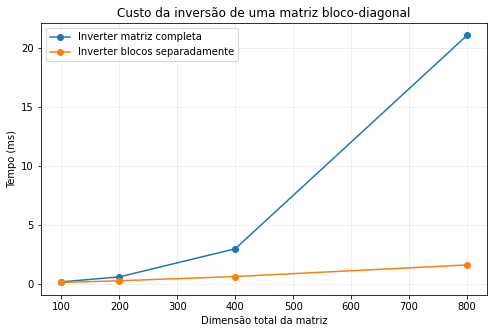

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    resultados["dim_total"],
    1000 * resultados["tempo_matriz_grande_s"],
    marker="o",
    label="Inverter matriz completa",
)

plt.plot(
    resultados["dim_total"],
    1000 * resultados["tempo_por_blocos_s"],
    marker="o",
    label="Inverter blocos separadamente",
)

plt.xlabel("Dimensão total da matriz")
plt.ylabel("Tempo (ms)")
plt.title("Custo da inversão de uma matriz bloco-diagonal")
plt.legend()
plt.grid(alpha=0.25)

plt.show()



## 6. Por que a diferença aumenta?

Se há $k$ blocos de dimensão $b\times b$, a matriz completa possui dimensão

$
n=kb.
$

Uma rotina genérica de inversão não necessariamente explora a informação de que todos os elementos fora dos blocos são zero. Seu custo denso é aproximadamente

$
O(n^3)
=
O((kb)^3)
=
O(k^3b^3).
$

Invertendo os blocos separadamente, temos $k$ inversões de matrizes $b\times b$:

$
k\,O(b^3)
=
O(kb^3).
$

A razão assintótica entre os custos é, portanto, aproximadamente

$
\frac{k^3b^3}{kb^3}
=
k^2.
$

Na prática, o ganho observado depende da implementação do BLAS/LAPACK, tamanho dos blocos, cache, paralelização e overhead do Python.



## 7. Economia de memória

Também existe uma diferença importante de armazenamento.

A matriz completa contém

$
(kb)^2 = k^2b^2
$

elementos.

Mantendo somente os blocos, armazenamos

$
kb^2
$

elementos.

Portanto, a razão de armazenamento é aproximadamente $k$. Para muitos blocos, evitar a construção da matriz completa pode ser tão importante quanto evitar sua inversão.



## 8. Melhor prática: não calcular a inversa se o objetivo é resolver um sistema

Em aplicações estatísticas e numéricas, muitas vezes não queremos explicitamente \(A^{-1}\). Queremos resolver

$
Ax=y.
$

Nesse caso, é preferível usar `np.linalg.solve`.

Para uma matriz bloco-diagonal,

$
A_i x_i = y_i
$

pode ser resolvido independentemente para cada bloco.


In [ ]:

k = 20
b = 20

local_rng = np.random.default_rng(321)

blocks = make_spd_blocks(k, b, local_rng)

y_blocks = [
    local_rng.standard_normal(b)
    for _ in range(k)
]

# Resolver bloco a bloco
t0 = perf_counter()

x_blocks = [
    np.linalg.solve(Ai, yi)
    for Ai, yi in zip(blocks, y_blocks)
]

tempo_solve_blocos = perf_counter() - t0

# Verificação
erros = [
    np.linalg.norm(Ai @ xi - yi)
    for Ai, xi, yi in zip(blocks, x_blocks, y_blocks)
]

print("Tempo solve por blocos:", tempo_solve_blocos)
print("Maior erro:", max(erros))


Tempo solve por blocos: 0.00024237099569290876
Maior erro: 1.942097114741681e-15



## 9. Comparação: `inv(A) @ y` versus `solve(A, y)`

Mesmo para um único bloco, `solve` é preferível a calcular explicitamente a inversa.


In [ ]:
b = 200
local_rng = np.random.default_rng(456)

X = local_rng.standard_normal((b, b))
A = X @ X.T + b * np.eye(b)
y = local_rng.standard_normal(b)

t0 = perf_counter()
x_inv = np.linalg.inv(A) @ y
tempo_inv = perf_counter() - t0

t0 = perf_counter()
x_solve = np.linalg.solve(A, y)
tempo_solve = perf_counter() - t0

print(f"inv(A) @ y : {tempo_inv:.6f} s")
print(f"solve(A,y) : {tempo_solve:.6f} s")
print(
    "Diferença entre as soluções:",
    np.linalg.norm(x_inv - x_solve)
)


inv(A) @ y : 0.022549 s
solve(A,y) : 0.000548 s
Diferença entre as soluções: 3.105121545680009e-17



## Conclusão

Quando a matriz é bloco-diagonal conhecida,

$A=\operatorname{diag}(A_1,\ldots,A_k),$

é preferível explorar essa estrutura diretamente.

Em vez de

```python
A = block_diag(*blocks)
Ainv = np.linalg.inv(A)
```

pode-se usar

```python
inv_blocks = [np.linalg.inv(Ai) for Ai in blocks]
```

e, se o objetivo for resolver sistemas lineares, melhor ainda:

```python
x_blocks = [
    np.linalg.solve(Ai, yi)
    for Ai, yi in zip(blocks, y_blocks)
]
```

Essa abordagem reduz custo computacional, memória e permite paralelização natural dos cálculos entre os blocos.
